# IT25101600 — Husain N.N
## Preprocessing Technique: Handling Missing Values

**Assigned dataset:** Real-World Style Fitness Classification Dataset (Synthetic)  
**Target variable:** `is_fit`  
**Assigned technique:** Detect and handle missing values in the `sleep_hours` column.

### Why this technique is needed
The dataset documentation states that `sleep_hours` contains approximately 8% missing
values (`NaN`), introduced deliberately to simulate a real-world data quality issue.
Missing values must be handled before the column can be used in any statistical
analysis or as input to a machine learning model, since most algorithms (and many
`pandas`/`numpy` operations) cannot process `NaN` values directly. Simply dropping
every row with a missing value would discard almost 1 in 12 records, so an
imputation strategy is more appropriate here.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('../data/raw/fitness_dataset.csv')
df.shape


(2000, 11)

In [2]:
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2000, 11)


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [3]:
# Step 1: Confirm the missing value problem
missing_summary = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)
pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct})


,missing_count,missing_pct
age,0,0.0
height_cm,0,0.0
weight_kg,0,0.0
heart_rate,0,0.0
blood_pressure,0,0.0
sleep_hours,160,8.0
nutrition_quality,0,0.0
activity_index,0,0.0
smokes,0,0.0
gender,0,0.0


`sleep_hours` is the only column with missing values, and the missing
rate (~8%) matches the dataset documentation. All other columns are complete.

In [4]:
print(f"Missing values in sleep_hours: {df['sleep_hours'].isna().sum()} out of {len(df)} rows")
print(f"Missing percentage: {df['sleep_hours'].isna().mean()*100:.2f}%")


Missing values in sleep_hours: 160 out of 2000 rows
Missing percentage: 8.00%


### EDA Visualization — Distribution of `sleep_hours` (before imputation)

A histogram is used to inspect the shape of the `sleep_hours` distribution (skew,
central tendency, spread) before deciding which imputation statistic (mean vs
median) is most appropriate.

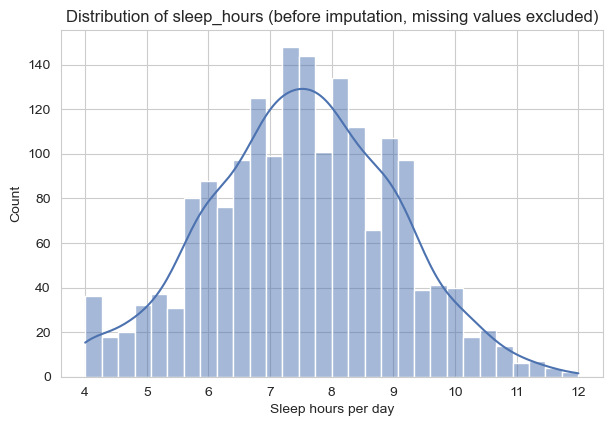

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.histplot(df['sleep_hours'].dropna(), bins=30, kde=True, color='#4C72B0', ax=ax)
ax.set_title('Distribution of sleep_hours (before imputation, missing values excluded)')
ax.set_xlabel('Sleep hours per day')
ax.set_ylabel('Count')
plt.show()


**Interpretation:** The distribution of `sleep_hours` is approximately
symmetric / bell-shaped with no strong skew, so the **mean** and **median** are close
to each other. Because the distribution is roughly symmetric and has no extreme
outliers, mean imputation is a reasonable and simple choice here.

In [6]:
# Step 2: Handle the missing values
mean_val = df['sleep_hours'].mean()
median_val = df['sleep_hours'].median()
print(f"Mean sleep_hours:   {mean_val:.3f}")
print(f"Median sleep_hours: {median_val:.3f}")

df_clean = df.copy()
df_clean['sleep_hours_missing_flag'] = df_clean['sleep_hours'].isna().astype(int)
df_clean['sleep_hours'] = df_clean['sleep_hours'].fillna(mean_val)

print("\nRemaining missing values in sleep_hours:", df_clean['sleep_hours'].isna().sum())


Mean sleep_hours:   7.513
Median sleep_hours: 7.500

Remaining missing values in sleep_hours: 0


### EDA Visualization — Distribution of `sleep_hours` (after imputation)

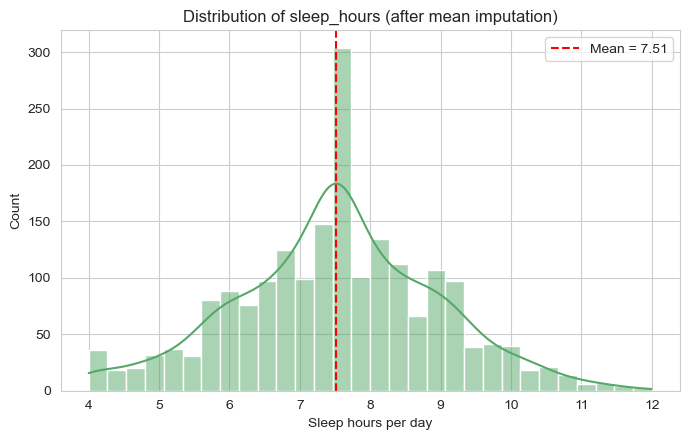

In [7]:
fig, ax = plt.subplots(figsize=(7,4.5))
sns.histplot(df_clean['sleep_hours'], bins=30, kde=True, color='#55A868', ax=ax)
ax.axvline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.2f}')
ax.set_title('Distribution of sleep_hours (after mean imputation)')
ax.set_xlabel('Sleep hours per day')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member1_sleep_hours_histogram.png', dpi=110, bbox_inches='tight')
plt.show()


**Interpretation:** After mean imputation, the overall shape of the
distribution is preserved and no new outliers are introduced — imputed values
reinforce the central peak at the mean (red dashed line). A
`sleep_hours_missing_flag` column was also kept so downstream models can, if useful,
learn from the fact that a value was originally missing.

### Justification recap
- **Technique:** Mean imputation for `sleep_hours` (~8% missing).
- **Why:** Distribution is roughly symmetric, so the mean is a stable, low-bias
  estimate; dropping rows would discard ~8% of the data unnecessarily.
- **Output:** `df_clean` — dataset with `sleep_hours` fully populated, ready to be
  merged into the group's combined pipeline.

In [8]:
df_clean.to_csv('../results/outputs/member1_missing_values_handled.csv', index=False)
print("Saved cleaned output to results/outputs/member1_missing_values_handled.csv")


Saved cleaned output to results/outputs/member1_missing_values_handled.csv
